Created new FCC lattice
----------------------------
n_fcc_cells = 4
N = 256
Target rho = 0.5
Actual rho = 0.5000000000000002
Density error = 2.220446049250313e-16
BoxLength = 7.999999999999999
FCC cell size = 1.9999999999999998
Saved lattice to:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2/FCC/n_cells_4/rho_0.500/lattice.gsd
Using GPU device
Final device: <hoomd.device.GPU object at 0x7fc774177850>


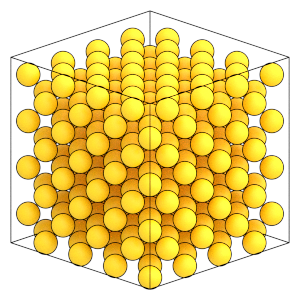

In [15]:
# ============================================================
# Render small FCC lattice
# ============================================================

import importlib

import md_Helpers.Create_Lattices as cl
import md_Helpers.Simulation_Helpers as sh
import md_Helpers.viz_helpers as vh

importlib.reload(cl)
importlib.reload(sh)
importlib.reload(vh)




# ============================================================
# Make small FCC lattice
# ============================================================

frame = cl.make_lattice_frame(
    n_fcc_cells=4,
    target_rho=0.50,
    overwrite = True,
)

# ============================================================
# Put frame into HOOMD simulation
# ============================================================

sim = sh.make_simulation(
    frame=frame,
    target_rho=0.50,
    kT=0.50,
)

sim.run(0)

# ============================================================
# Render
# ============================================================

vh.render(sim.state.get_snapshot())

In [14]:
result = sh.get_or_make_thermalized_state(
    n_fcc_cells=4,
    target_rho=0.50,
    kT=0.50,
    nsteps=100,
    log_period=10,
    seed=1,
    phase_name="simulation_helper_test",
    overwrite=True,
)

Loaded existing FCC lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2/FCC/n_cells_4/rho_0.500/lattice.gsd
Using GPU device
Final device: <hoomd.device.GPU object at 0x7fc2640d6e40>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_4/rho_0.500/kT_0.500/nsteps_100/seed_1/simulation_helper_test_log.hdf5
Log period: 10
Stopped HDF5 logger
Wrote HDF5 metadata
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_4/rho_0.500/kT_0.500/nsteps_100/seed_1/simulation_helper_test_log.hdf5
Metadata group: metadata
Saved final state
GSD file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_4/rho_0.500/kT_0.500/nsteps_100/seed_1/simulation_helper_test.gsd


In [17]:
# ============================================================
# Test 1: Reload helpers and check V2 paths
# ============================================================

import importlib
from pathlib import Path

import md_Helpers.Project_Paths as pp
import md_Helpers.Create_Lattices as cl
import md_Helpers.Logging_Helpers as lh
import md_Helpers.Simulation_Helpers as sh
import md_Helpers.viz_helpers as vh

importlib.reload(pp)
importlib.reload(cl)
importlib.reload(lh)
importlib.reload(sh)
importlib.reload(vh)

print("SIMPLE_LATTICES_V2_ROOT:")
print(pp.SIMPLE_LATTICES_V2_ROOT)

print("\nTHERMALIZED_STATES_V2_ROOT:")
print(pp.THERMALIZED_STATES_V2_ROOT)

lattice_path = cl.get_lattice_path(
    n_fcc_cells=4,
    target_rho=0.50,
)

phase_paths = lh.get_phase_paths(
    n_fcc_cells=4,
    target_rho=0.50,
    kT=0.50,
    nsteps=100,
    seed=1,
    phase_name="test",
)

print("\nExample lattice path:")
print(lattice_path)

print("\nExample thermalized state path:")
print(phase_paths["state_path"])

assert "Simple_Lattices_v2" in str(lattice_path)
assert "Thermalized_States_v2" in str(phase_paths["state_path"])
assert "BoxLength" not in str(lattice_path)
assert "BoxLength" not in str(phase_paths["state_path"])

print("\nPASSED: V2 paths are being used.")

SIMPLE_LATTICES_V2_ROOT:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2

THERMALIZED_STATES_V2_ROOT:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2

Example lattice path:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2/FCC/n_cells_4/rho_0.500/lattice.gsd

Example thermalized state path:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_4/rho_0.500/kT_0.500/nsteps_100/seed_1/test.gsd

PASSED: V2 paths are being used.


In [18]:
# ============================================================
# Test 2: Check FCC lattice construction
# ============================================================

import numpy as np

n_fcc_cells = 4
target_rho = 0.50

info = cl.get_fcc_lattice_info(
    n_fcc_cells=n_fcc_cells,
    target_rho=target_rho,
)

print("FCC lattice info:")
for key, value in info.items():
    print(key, "=", value)

assert info["N"] == 4 * n_fcc_cells**3
assert np.isclose(info["BoxLength"], 8.0)
assert np.isclose(info["actual_rho"], target_rho)
assert np.isclose(info["fcc_cell_size"], 2.0)

positions, info2 = cl.FillFccLattice(
    n_fcc_cells=n_fcc_cells,
    target_rho=target_rho,
)

print("\npositions.shape =", positions.shape)

assert positions.shape == (256, 3)

L = info["BoxLength"]

assert np.all(positions[:, 0] >= -L / 2)
assert np.all(positions[:, 0] < L / 2)
assert np.all(positions[:, 1] >= -L / 2)
assert np.all(positions[:, 1] < L / 2)
assert np.all(positions[:, 2] >= -L / 2)
assert np.all(positions[:, 2] < L / 2)

print("\nPASSED: FCC lattice construction is consistent.")

FCC lattice info:
lattice_type = fcc
density_mode = fixed_N_variable_L
n_fcc_cells = 4
N = 256
target_rho = 0.5
actual_rho = 0.5000000000000002
BoxLength = 7.999999999999999
volume = 512.0
fcc_cell_size = 1.9999999999999998

positions.shape = (256, 3)

PASSED: FCC lattice construction is consistent.


In [19]:
# ============================================================
# Test 3: Make and save V2 lattice frame
# ============================================================

n_fcc_cells = 4
target_rho = 0.50

frame = cl.make_lattice_frame(
    n_fcc_cells=n_fcc_cells,
    target_rho=target_rho,
    overwrite=True,
)

lattice_path = cl.get_lattice_path(
    n_fcc_cells=n_fcc_cells,
    target_rho=target_rho,
)

print("\nLattice path:")
print(lattice_path)

print("\nFrame info:")
print("N =", frame.particles.N)
print("Box =", frame.configuration.box)

assert lattice_path.exists()
assert frame.particles.N == 256
assert np.isclose(frame.configuration.box[0], 8.0)

print("\nPASSED: lattice frame was created and saved.")

Created new FCC lattice
----------------------------
n_fcc_cells = 4
N = 256
Target rho = 0.5
Actual rho = 0.5000000000000002
Density error = 2.220446049250313e-16
BoxLength = 7.999999999999999
FCC cell size = 1.9999999999999998
Saved lattice to:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2/FCC/n_cells_4/rho_0.500/lattice.gsd

Lattice path:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2/FCC/n_cells_4/rho_0.500/lattice.gsd

Frame info:
N = 256
Box = [7.999999999999999, 7.999999999999999, 7.999999999999999, 0, 0, 0]

PASSED: lattice frame was created and saved.


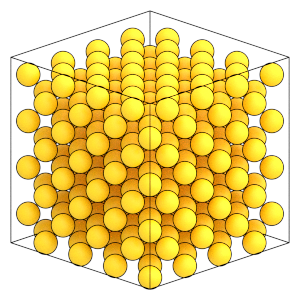

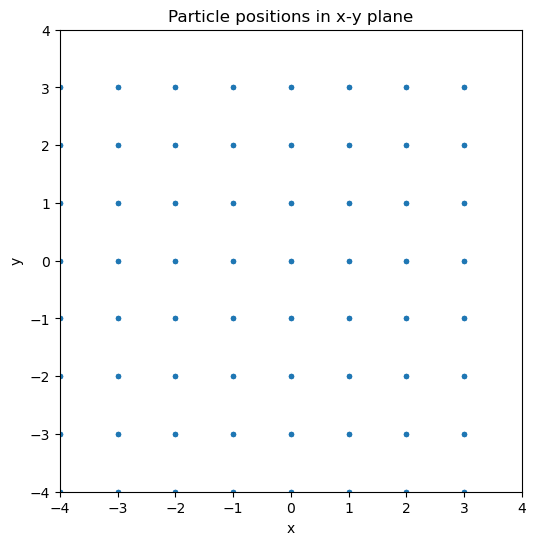

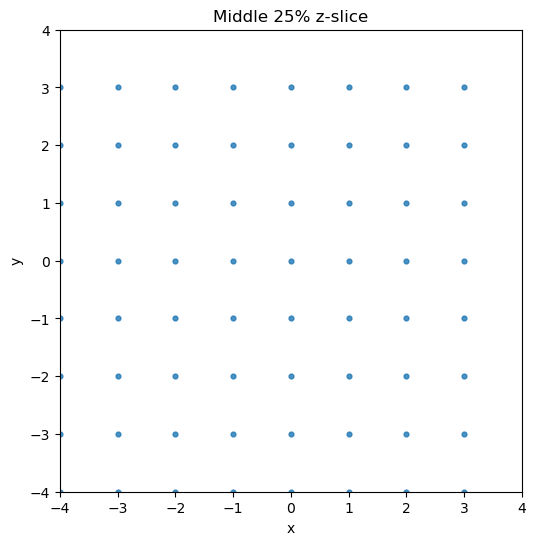

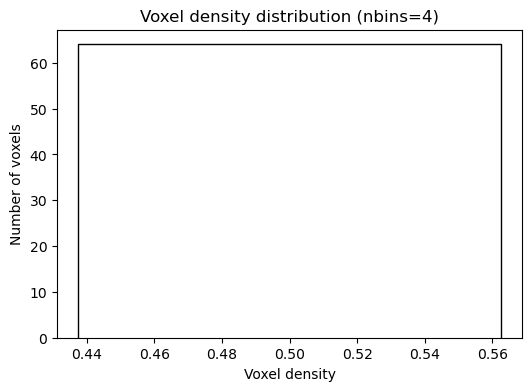

Histogram output:
(array([64]), array([0.4375, 0.5625]))

PASSED: visualization helpers work directly on frame.


In [20]:
# ============================================================
# Test 4: Visualization from GSD frame
# ============================================================

# Render directly from frame
display(vh.render(frame))

# XY plots directly from frame
vh.plot_xy_particles(
    frame,
    point_size=8,
    alpha=0.8,
)

vh.plot_xy_slice(
    frame,
    fraction=0.25,
    point_size=12,
    alpha=0.8,
)

hist = vh.plot_voxel_histogram(
    frame,
    nbins=4,
)

print("Histogram output:")
print(hist)

print("\nPASSED: visualization helpers work directly on frame.")

In [21]:
# ============================================================
# Test 5: Make simulation and run without logging
# ============================================================

n_fcc_cells = 4
target_rho = 0.50
kT = 0.50
seed = 1

lattice_path = cl.get_lattice_path(
    n_fcc_cells=n_fcc_cells,
    target_rho=target_rho,
)

sim = sh.make_simulation(
    frame=frame,
    target_rho=target_rho,
    n_fcc_cells=n_fcc_cells,
    seed=seed,
    kT=kT,
    starting_state_path=str(lattice_path),
)

print("\nSimulation metadata:")
for key, value in sim.metadata.items():
    print(key, "=", value)

assert sim.metadata["n_fcc_cells"] == n_fcc_cells
assert sim.metadata["N"] == 256
assert np.isclose(sim.metadata["actual_rho"], target_rho)
assert np.isclose(sim.metadata["BoxLength"], 8.0)
assert np.isclose(sim.metadata["fcc_cell_size"], 2.0)

sim = sh.thermalize_and_randomize(
    simulation=sim,
    kT=kT,
    nsteps=10,
    log=False,
)

print("\nFinal timestep:", sim.timestep)

assert sim.timestep == 10

print("\nPASSED: simulation can run without logging.")

Using GPU device
Final device: <hoomd.device.GPU object at 0x7fc264135640>

Simulation metadata:
lattice_type = fcc
density_mode = fixed_N_variable_L
n_fcc_cells = 4
N = 256
target_rho = 0.5
actual_rho = 0.5000000000000002
BoxLength = 7.999999999999999
volume = 511.99999999999983
fcc_cell_size = 1.9999999999999998
seed = 1
dt = 0.005
kT = 0.5
epsilon_LJ = 1.0
sigma_LJ = 1.0
r_cut_LJ = 2.5
buffer_LJ = 0.4
lj_mode = xplor
r_on_LJ = 2.0
starting_state_path = /exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2/FCC/n_cells_4/rho_0.500/lattice.gsd

Final timestep: 10

PASSED: simulation can run without logging.


In [22]:
# ============================================================
# Test 6: Full V2 workflow with logging
# ============================================================

import time

phase_name = f"full_v2_test_{int(time.time())}"

result = sh.get_or_make_thermalized_state(
    n_fcc_cells=4,
    target_rho=0.50,
    kT=0.50,
    nsteps=100,
    log_period=10,
    seed=1,
    phase_name=phase_name,
    overwrite=True,
    overwrite_lattice=False,
)

paths = result["paths"]

print("\nReturned paths:")
for key, value in paths.items():
    print(key, "=", value)

print("\nFile checks:")
print("folder exists:", paths["folder"].exists())
print("state exists: ", paths["state_path"].exists())
print("log exists:   ", paths["log_path"].exists())

assert paths["folder"].exists()
assert paths["state_path"].exists()
assert paths["log_path"].exists()

assert "Thermalized_States_v2" in str(paths["state_path"])
assert "n_cells_4" in str(paths["state_path"])
assert "rho_0.500" in str(paths["state_path"])
assert "kT_0.500" in str(paths["state_path"])
assert "nsteps_100" in str(paths["state_path"])
assert "seed_1" in str(paths["state_path"])

print("\nPASSED: full V2 logged workflow completed.")

Loaded existing FCC lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2/FCC/n_cells_4/rho_0.500/lattice.gsd
Using GPU device
Final device: <hoomd.device.GPU object at 0x7fc23d7b1250>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_4/rho_0.500/kT_0.500/nsteps_100/seed_1/full_v2_test_1781206860_log.hdf5
Log period: 10
Stopped HDF5 logger
Wrote HDF5 metadata
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_4/rho_0.500/kT_0.500/nsteps_100/seed_1/full_v2_test_1781206860_log.hdf5
Metadata group: metadata
Saved final state
GSD file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_4/rho_0.500/kT_0.500/nsteps_100/seed_1/full_v2_test_1781206860.gsd

Returned paths:
folder = /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_4/rho_0.500/kT_0.500/nsteps_100/seed_1
log_path = /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_4/rho_0.500/kT_0.500

In [23]:
# ============================================================
# Test 7: Read log and check metadata
# ============================================================

log = lh.read_hdf5_log(paths["log_path"])

print("Top-level HDF5 keys:")
print(log.keys())

metadata = log["metadata"]["attrs"]

print("\nMetadata:")
for key in sorted(metadata.keys()):
    print(key, "=", metadata[key])

required_keys = [
    "phase_name",
    "lattice_type",
    "density_mode",
    "n_fcc_cells",
    "N",
    "target_rho",
    "actual_rho",
    "BoxLength",
    "fcc_cell_size",
    "kT",
    "nsteps",
    "log_period",
    "seed",
    "starting_state_path",
    "phase_separated",
    "state_path",
    "log_path",
]

for key in required_keys:
    assert key in metadata, f"Missing metadata key: {key}"

assert metadata["lattice_type"] == "fcc"
assert metadata["density_mode"] == "fixed_N_variable_L"
assert int(metadata["n_fcc_cells"]) == 4
assert int(metadata["N"]) == 256
assert np.isclose(metadata["target_rho"], 0.50)
assert np.isclose(metadata["actual_rho"], 0.50)
assert np.isclose(metadata["BoxLength"], 8.0)
assert np.isclose(metadata["fcc_cell_size"], 2.0)

print("\nPASSED: HDF5 metadata looks correct.")

Top-level HDF5 keys:
dict_keys(['hoomd-data', 'metadata'])

Metadata:
BoxLength = 8.0
Lx = 8.0
Ly = 8.0
Lz = 8.0
N = 256
actual_rho = 0.5
buffer_LJ = 0.4
density_mode = fixed_N_variable_L
dt = 0.005
epsilon_LJ = 1.0
fcc_cell_size = 2.0
final_timestep = 100
kT = 0.5
lattice_type = fcc
lj_mode = xplor
log_path = /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_4/rho_0.500/kT_0.500/nsteps_100/seed_1/full_v2_test_1781206860_log.hdf5
log_period = 10
n_fcc_cells = 4
nsteps = 100
phase_name = full_v2_test_1781206860
phase_separated = True
r_cut_LJ = 2.5
r_on_LJ = 2.0
seed = 1
sigma_LJ = 1.0
starting_state_path = /exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2/FCC/n_cells_4/rho_0.500/lattice.gsd
state_path = /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_4/rho_0.500/kT_0.500/nsteps_100/seed_1/full_v2_test_1781206860.gsd
target_rho = 0.5
volume = 512.0

PASSED: HDF5 metadata looks correct.


In [24]:
# ============================================================
# Test 8: Check thermodynamic log arrays
# ============================================================

timesteps = log["hoomd-data"]["Simulation"]["timestep"]

thermo = (
    log["hoomd-data"]["md"]
       ["compute"]
       ["ThermodynamicQuantities"]
)

pressure = thermo["pressure"]
potential_energy = thermo["potential_energy"]
kinetic_energy = thermo["kinetic_energy"]
kinetic_temperature = thermo["kinetic_temperature"]

print("Logged timesteps:", timesteps)
print("Number of log points:", len(timesteps))
print("Pressure shape:", pressure.shape)
print("Potential energy shape:", potential_energy.shape)
print("Kinetic energy shape:", kinetic_energy.shape)
print("Kinetic temperature shape:", kinetic_temperature.shape)

assert len(timesteps) > 0
assert len(pressure) == len(timesteps)
assert len(potential_energy) == len(timesteps)
assert len(kinetic_energy) == len(timesteps)
assert len(kinetic_temperature) == len(timesteps)

assert np.all(np.isfinite(pressure))
assert np.all(np.isfinite(potential_energy))
assert np.all(np.isfinite(kinetic_energy))
assert np.all(np.isfinite(kinetic_temperature))

print("\nPASSED: thermodynamic log arrays look good.")

Logged timesteps: [ 10  20  30  40  50  60  70  80  90 100]
Number of log points: 10
Pressure shape: (10,)
Potential energy shape: (10,)
Kinetic energy shape: (10,)
Kinetic temperature shape: (10,)

PASSED: thermodynamic log arrays look good.


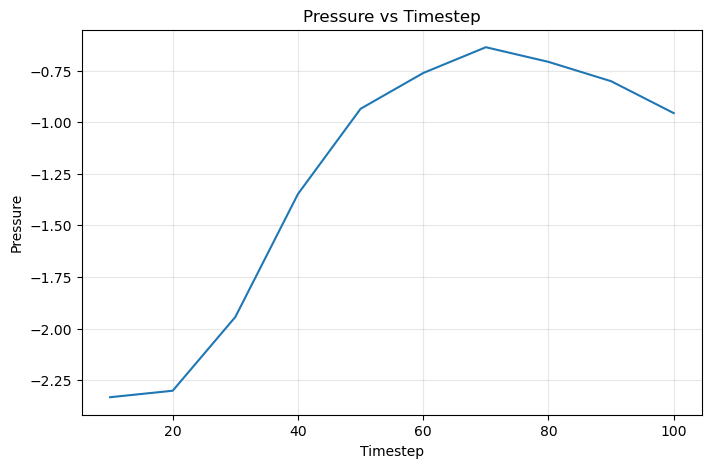

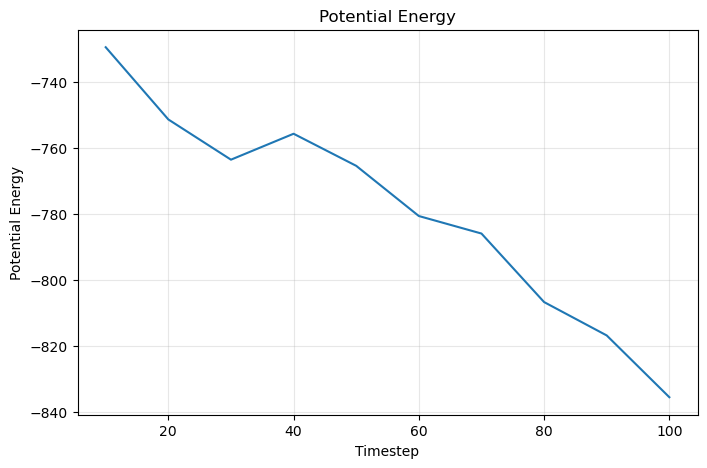

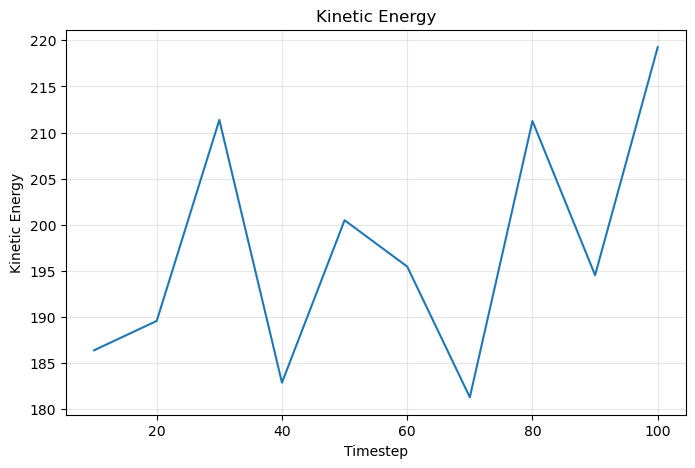

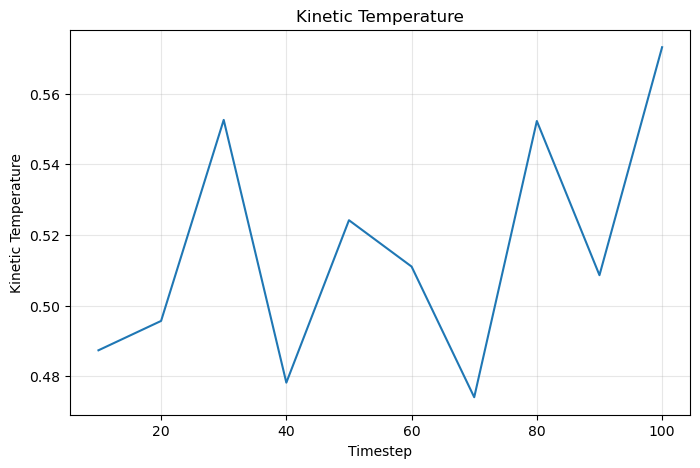


PASSED: log plotting functions work.


In [25]:
# ============================================================
# Test 9: Plot logged quantities
# ============================================================

vh.plot_pressure_log(log)

vh.plot_log_quantity(
    log,
    "potential_energy",
)

vh.plot_log_quantity(
    log,
    "kinetic_energy",
)

vh.plot_log_quantity(
    log,
    "kinetic_temperature",
)

print("\nPASSED: log plotting functions work.")

In [26]:
# ============================================================
# Test 10: Load existing thermalized state
# ============================================================

result_loaded = sh.get_or_make_thermalized_state(
    n_fcc_cells=4,
    target_rho=0.50,
    kT=0.50,
    nsteps=100,
    log_period=10,
    seed=1,
    phase_name=phase_name,
    overwrite=False,
)

print("created_new =", result_loaded["created_new"])
print("frame N =", result_loaded["frame"].particles.N)
print("state path =", result_loaded["paths"]["state_path"])

assert result_loaded["created_new"] is False
assert result_loaded["frame"].particles.N == 256

print("\nPASSED: existing thermalized state loads correctly.")

Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_4/rho_0.500/kT_0.500/nsteps_100/seed_1/full_v2_test_1781206860.gsd
created_new = False
frame N = 256
state path = /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_4/rho_0.500/kT_0.500/nsteps_100/seed_1/full_v2_test_1781206860.gsd

PASSED: existing thermalized state loads correctly.


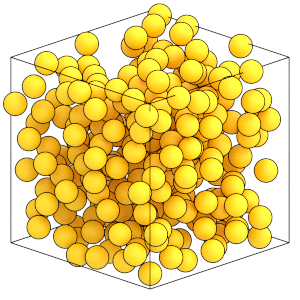

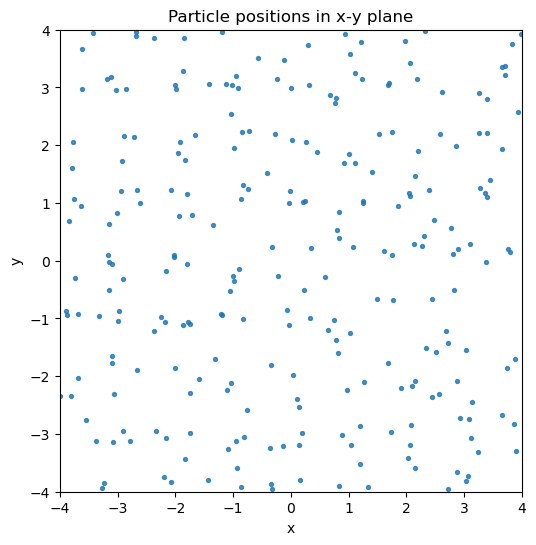

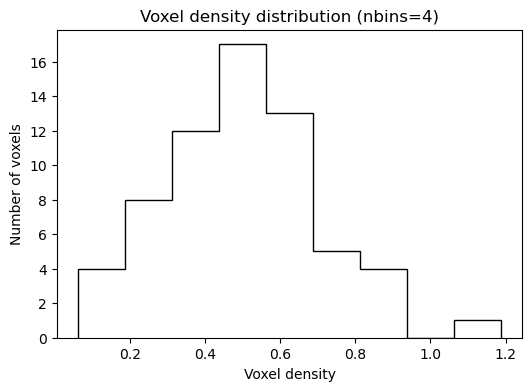


PASSED: final randomized frame visualizes correctly.


In [27]:
# ============================================================
# Test 11: Render final randomized frame
# ============================================================

final_frame = result["frame"]

display(vh.render(final_frame))

vh.plot_xy_particles(
    final_frame,
    point_size=8,
    alpha=0.8,
)

vh.plot_voxel_histogram(
    final_frame,
    nbins=4,
)

print("\nPASSED: final randomized frame visualizes correctly.")